In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import models,applications,layers,losses,callbacks
from sklearn.metrics import confusion_matrix,classification_report
import numpy as np
import seaborn as sn
import pathlib
import PIL
import cv2
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [5]:
# Download and extract TensorFlow flower dataset
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flowers', origin=dataset_url,
                                   cache_subdir='/path', untar=True)


228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# Convert directory path to Path object
data_dir=pathlib.Path(data_dir)
print('path:',data_dir)

In [7]:
# Check number of images
count=len(list(data_dir.glob('**/*.jpg')))
print('The number of images:',count)

The number of images: 3670


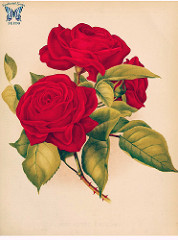

In [8]:
# Show an image
roses=list(data_dir.glob('**/roses/*'))
PIL.Image.open(str(roses[0]))

In [9]:
# Organize image file paths and map them to integer class labels
flwers_img_dict = {
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'roses': list(data_dir.glob('*/roses/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*'))
}
flwers_lbl_dict = {
    'daisy': 0,
    'dandelion': 1,
    'roses': 2,
    'sunflowers': 3,
    'tulips': 4
}


In [10]:
# Reading an image as numpy array
img=cv2.imread(str(flwers_img_dict['roses'][0]))
print('numpy array of an image:\n',img)

numpy array of an image:
 [[[255 254 254]
  [248 253 252]
  [244 250 249]
  ...
  [255 249 254]
  [255 248 254]
  [255 248 254]]

 [[127 174 225]
  [134 191 236]
  [127 179 219]
  ...
  [152 197 234]
  [144 198 233]
  [144 198 233]]

 [[174 202 232]
  [163 200 228]
  [167 204 232]
  ...
  [170 207 235]
  [173 207 237]
  [173 207 237]]

 ...

 [[252 245 252]
  [253 246 253]
  [253 246 253]
  ...
  [253 249 255]
  [249 245 251]
  [249 245 251]]

 [[254 247 254]
  [254 247 254]
  [253 246 253]
  ...
  [251 243 253]
  [252 248 254]
  [252 248 254]]

 [[249 246 255]
  [248 245 254]
  [248 245 254]
  ...
  [254 245 255]
  [250 243 255]
  [250 243 255]]]


In [11]:
# check number of images in each type of flowers
for fldr_name,images in flwers_img_dict.items():
  print(fldr_name)
  print(len(images))

daisy
633
dandelion
898
roses
641
sunflowers
699
tulips
799


In [13]:
# Creat X,Y and resize
X,Y=[],[]
for flwr_name,images in flwers_img_dict.items():
  for image in images:
    img=cv2.imread(str(image))
    resized_img=cv2.resize(img,(100,100))
    X.append(resized_img)
    Y.append(flwers_lbl_dict[flwr_name])

In [14]:
# Converting X,Y to array
X=np.array(X)
Y=np.array(Y)
print('X:\n',X)
print('Y\n',Y)

X:
 [[[[  2  10   8]
   [  2   9   6]
   [  2   7   5]
   ...
   [163 210 225]
   [172 213 228]
   [179 215 229]]

  [[  3  12   9]
   [  2  11   8]
   [  2   9   6]
   ...
   [176 215 231]
   [184 217 232]
   [185 216 231]]

  [[  2  15  11]
   [  2  13  10]
   [  3  12   9]
   ...
   [183 217 232]
   [190 219 234]
   [187 219 232]]

  ...

  [[  3  11  10]
   [  3  11  10]
   [  3  11   9]
   ...
   [ 58  85  98]
   [ 59  84  92]
   [ 56  81  89]]

  [[  2  10   9]
   [  3  11  10]
   [  2  11   9]
   ...
   [ 51  79  88]
   [ 62  89 100]
   [ 60  82  88]]

  [[  2  10   9]
   [  3  10  10]
   [  2  10   9]
   ...
   [ 38  62  72]
   [ 53  83  96]
   [ 60  88 102]]]


 [[[ 48  91  61]
   [ 51  96  66]
   [ 48  93  60]
   ...
   [ 23  54  55]
   [ 25  69  64]
   [ 23  70  59]]

  [[ 56 101  72]
   [ 50  96  67]
   [ 50  92  61]
   ...
   [ 19  50  48]
   [ 18  50  50]
   [ 16  54  52]]

  [[ 49 101  61]
   [ 43  92  60]
   [ 41  89  55]
   ...
   [ 25  46  47]
   [ 18  46  47]
   [ 14

In [15]:
# Split the data
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=0)
print('size of X_train:',X_train.shape) # check size of X_train
print('size of X_test:',X_test.shape) # check size of X_test
print('size of Y_train:',Y_train.shape) # check size of Y_train
print('size of Y_test:',Y_test.shape) # check size of Y_test

size of X_train: (2752, 100, 100, 3)
size of X_test: (918, 100, 100, 3)
size of Y_train: (2752,)
size of Y_test: (918,)


In [16]:
# Normalize the pixel values to the range [0, 1]
X_train=X_train/255
X_test=X_test/255

In [17]:
# Data augmentation to enhance model robustness
data_aug=tf.keras.Sequential([
    layers.RandomZoom(0.3),
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])

In [18]:
# Define input shape for the MobileNetV2 model
input_shape = (100,100)
IMG_SIZE = input_shape + (3,)

In [22]:
# Function to create and compile the model
def my_model():
  # Load VGG16 as a feature extractor without the top classification layer
  network=applications.VGG16(input_shape=IMG_SIZE,
                             include_top=False,
                             weights='imagenet')
  network.trainable=False   # Freeze weights to prevent retraining
  model=models.Sequential([
      data_aug,
      network,
      layers.Flatten(),
      layers.Dense(128,activation='relu'),
      layers.Dense(64,activation='relu'),
      layers.Dense(32,activation='relu'),
      layers.Dense(5,activation='softmax')
  ])
  model.compile(
      optimizer='adam',
      loss=losses.sparse_categorical_crossentropy,
      metrics=['accuracy']
  )
  return model


# Function to evaluate the model
def eval(model, X, Y):
    model.evaluate(X, Y)

# Function for making predictions
def prediction(model, X, Y):
    Y_predict = model.predict(X)
    Y_pred = [np.argmax(i) for i in Y_predict]
    print('Predicted the first five labels:', Y_pred[:5])
    print('True labels of the first five elements:', Y[:5])
    return Y_pred

# Function to display classification report and confusion matrix
def report(truth, predictions):
    print(classification_report(truth, predictions))
    cm = tf.math.confusion_matrix(labels=truth, predictions=predictions)
    plt.figure(figsize=(10, 7))
    sn.heatmap(cm, annot=True, fmt='d')
    plt.xlabel('Predicted')
    plt.ylabel('Truth')

# Function to plot training and validation loss
def plot_loss(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid()
    plt.show()

# Function to plot training and validation accuracy
def plot_accuracy(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid()
    plt.show()

In [24]:

# Create and train the model
model=my_model() # Instantiate the model
tb_callback=callbacks.TensorBoard(log_dir='/content/drive/logs',histogram_freq=1) # Set up TensorBoard callback
history=model.fit(X_train,Y_train,epochs= 20,validation_split=0.2,callbacks=tb_callback) # Train the model

Epoch 1/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 345s 5s/step - accuracy: 0.5055 - loss: 1.2203 - val_accuracy: 0.7114 - val_loss: 0.8010
Epoch 2/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 377s 5s/step - accuracy: 0.6849 - loss: 0.7972 - val_accuracy: 0.7405 - val_loss: 0.7098
Epoch 3/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 397s 5s/step - accuracy: 0.7466 - loss: 0.6848 - val_accuracy: 0.7205 - val_loss: 0.7268
Epoch 4/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 383s 5s/step - accuracy: 0.7493 - loss: 0.6638 - val_accuracy: 0.7332 - val_loss: 0.6859
Epoch 5/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 381s 5s/step - accuracy: 0.7474 - loss: 0.6398 - val_accuracy: 0.7296 - val_loss: 0.6958
Epoch 6/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 355s 5s/step - accuracy: 0.7788 - loss: 0.5737 - val_accuracy: 0.7278 - val_loss: 0.7890
Epoch 7/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 336s 5s/step - accuracy: 0.7745 - loss: 0.5663 - val_accuracy: 0.7768 - val_loss: 0.6611
Epoch 8/20
69/69 ━━━━━━━━━━━━━━━━━━━━ 398s 5s/step - accuracy: 0.7646 - loss: 0.5866 - val_accuracy: 0.7695 - v

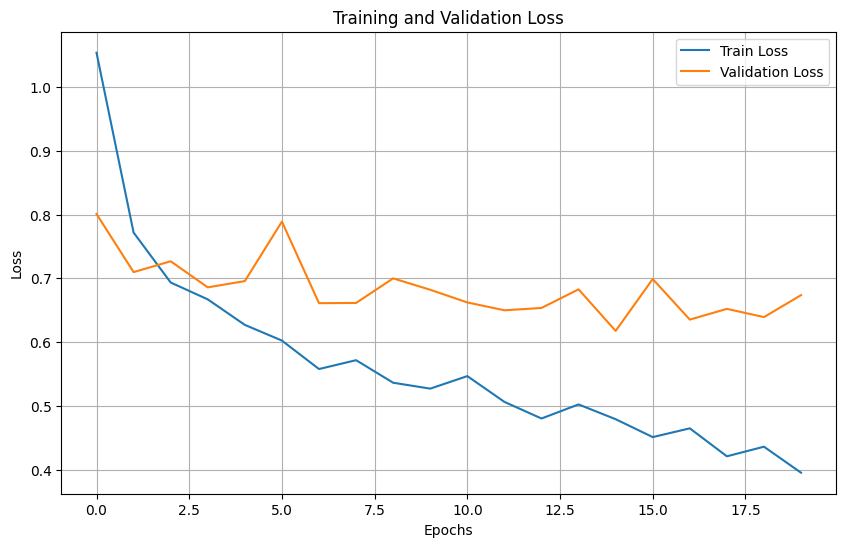

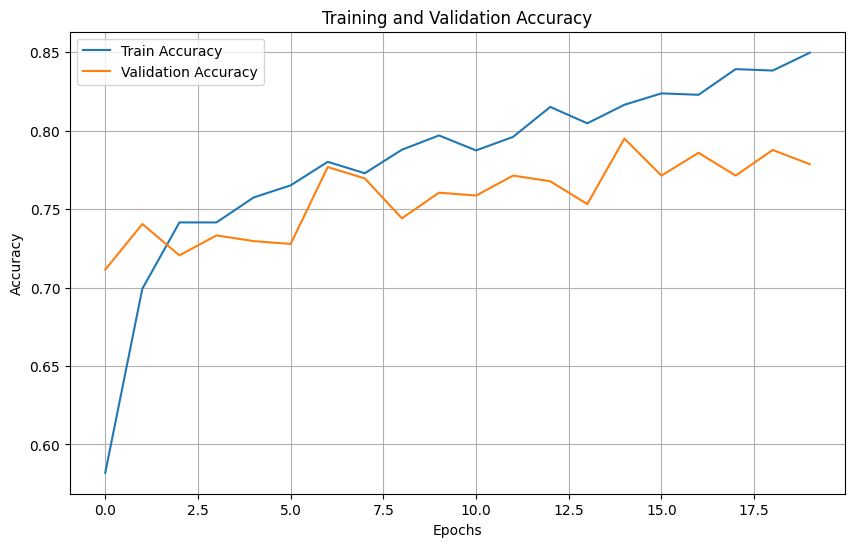

In [25]:
# Plot training and validation loss and accuracy
plot_loss(history)
plot_accuracy(history)

In [27]:
# Evaluate the model on the test set
eval(model,X_test,Y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 109s 4s/step - accuracy: 0.7979 - loss: 0.6012


In [28]:
# Make predictions
preds=prediction(model,X_test,Y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 110s 4s/step
Predicted the first five labels: [np.int64(1), np.int64(0), np.int64(2), np.int64(4), np.int64(2)]
True labels of the first five elements: [1 0 2 4 2]


              precision    recall  f1-score   support

           0       0.81      0.82      0.81       173
           1       0.80      0.87      0.83       231
           2       0.79      0.79      0.79       152
           3       0.80      0.73      0.76       150
           4       0.82      0.78      0.80       212

    accuracy                           0.80       918
   macro avg       0.80      0.80      0.80       918
weighted avg       0.80      0.80      0.80       918



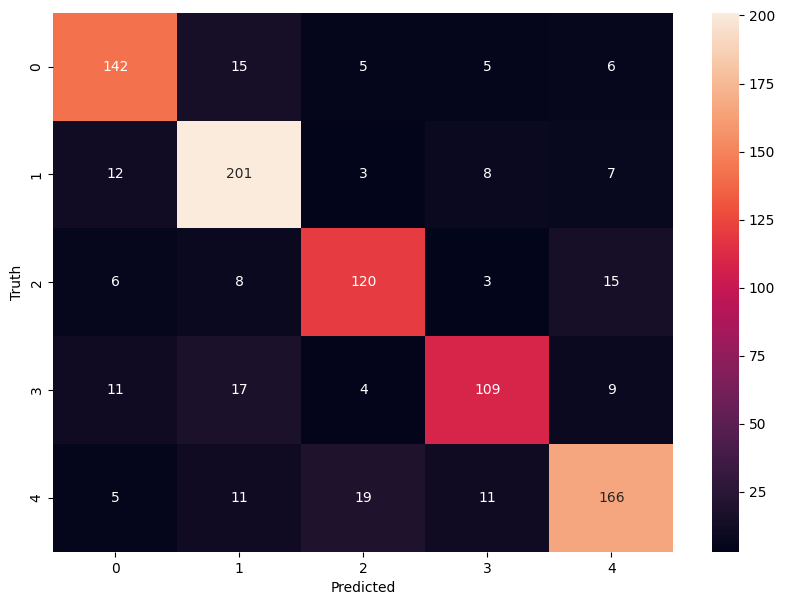

In [29]:
#Generate a report
report(Y_test,preds)